#### Импорты

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from tqdm import tqdm
from torchvision import models
import scipy.ndimage as ndi
import pandas as pd


torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

#### Часть A (S10)

Был выбран датасет `STL10` 

In [2]:
# базовый transform для CNN
basic_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

# аугментации
aug_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# transform для ResNet
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


In [3]:
# STL10
train_full = torchvision.datasets.STL10(
    root="./data", split="train", download=True, transform=basic_transform
)
test_set = torchvision.datasets.STL10(
    root="./data", split="test", download=True, transform=basic_transform
)

val_size = int(0.2 * len(train_full))
train_size = len(train_full) - val_size
train_set, val_set = random_split(train_full, [train_size, val_size])


100%|██████████| 2.64G/2.64G [18:30<00:00, 2.38MB/s]  


x.shape: torch.Size([64, 3, 96, 96]) y.shape: torch.Size([64])


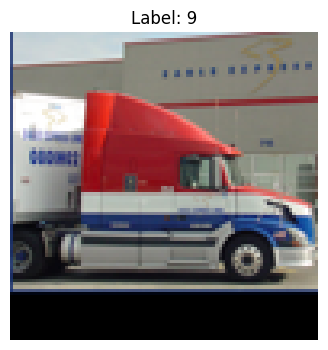

In [4]:
batch_size = 64

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

x, y = next(iter(train_loader))
print("x.shape:", x.shape, "y.shape:", y.shape)

plt.figure(figsize=(4,4))
plt.imshow(np.transpose(x[0], (1,2,0)))
plt.title(f"Label: {y[0].item()}")
plt.axis("off")
plt.show()


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (preds.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = criterion(preds, y)
            total_loss += loss.item() * x.size(0)
            correct += (preds.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


In [7]:
def run_experiment(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0
    best_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

        print(f"Epoch {epoch+1}/{epochs} | val_acc={val_acc:.4f}")

    return best_state, best_val_acc, history


##### Экперименты

C1: simple-cnn-base

In [9]:
train_full.transform = basic_transform  # без аугментаций
model_c1 = SimpleCNN()
state_c1, acc_c1, hist_c1 = run_experiment(model_c1, train_loader, val_loader, epochs=10, lr=1e-3)


Epoch 1/10 | val_acc=0.3910
Epoch 2/10 | val_acc=0.4470
Epoch 3/10 | val_acc=0.4470
Epoch 4/10 | val_acc=0.5180
Epoch 5/10 | val_acc=0.5400
Epoch 6/10 | val_acc=0.5530
Epoch 7/10 | val_acc=0.5600
Epoch 8/10 | val_acc=0.5630
Epoch 9/10 | val_acc=0.5660
Epoch 10/10 | val_acc=0.5590


C2: simple-cnn-aug

In [10]:
train_full.transform = aug_transform  # с аугментациями
model_c2 = SimpleCNN()
state_c2, acc_c2, hist_c2 = run_experiment(model_c2, train_loader, val_loader, epochs=10, lr=1e-3)


Epoch 1/10 | val_acc=0.3240
Epoch 2/10 | val_acc=0.4320
Epoch 3/10 | val_acc=0.4650
Epoch 4/10 | val_acc=0.5270
Epoch 5/10 | val_acc=0.5230
Epoch 6/10 | val_acc=0.5690
Epoch 7/10 | val_acc=0.5590
Epoch 8/10 | val_acc=0.5500
Epoch 9/10 | val_acc=0.5880
Epoch 10/10 | val_acc=0.5860


C3: resnet18-head-only

In [11]:
train_full.transform = resnet_transform

model_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in model_c3.parameters():
    p.requires_grad = False
model_c3.fc = nn.Linear(512, 10)

state_c3, acc_c3, hist_c3 = run_experiment(model_c3, train_loader, val_loader, epochs=10, lr=1e-3)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ASUS Vivobook Flip S/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 9.97MB/s]


Epoch 1/10 | val_acc=0.9140
Epoch 2/10 | val_acc=0.9220
Epoch 3/10 | val_acc=0.9360
Epoch 4/10 | val_acc=0.9390
Epoch 5/10 | val_acc=0.9390
Epoch 6/10 | val_acc=0.9390
Epoch 7/10 | val_acc=0.9440
Epoch 8/10 | val_acc=0.9390
Epoch 9/10 | val_acc=0.9410
Epoch 10/10 | val_acc=0.9470


C4: resnet18-finetune

In [12]:
model_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for name, p in model_c4.named_parameters():
    p.requires_grad = ("layer4" in name) or ("fc" in name)
model_c4.fc = nn.Linear(512, 10)

state_c4, acc_c4, hist_c4 = run_experiment(model_c4, train_loader, val_loader, epochs=10, lr=1e-4)


Epoch 1/10 | val_acc=0.9380
Epoch 2/10 | val_acc=0.9430
Epoch 3/10 | val_acc=0.9490
Epoch 4/10 | val_acc=0.9520
Epoch 5/10 | val_acc=0.9480
Epoch 6/10 | val_acc=0.9490
Epoch 7/10 | val_acc=0.9490
Epoch 8/10 | val_acc=0.9490
Epoch 9/10 | val_acc=0.9520
Epoch 10/10 | val_acc=0.9510


Выбор лучшей модели и тест один раз

In [13]:
results_val = {
    "C1": acc_c1,
    "C2": acc_c2,
    "C3": acc_c3,
    "C4": acc_c4,
}
best_id = max(results_val, key=results_val.get)
best_state = {"C1": state_c1, "C2": state_c2, "C3": state_c3, "C4": state_c4}[best_id]
print("Best experiment:", best_id, "val_acc:", results_val[best_id])


Best experiment: C4 val_acc: 0.952


In [14]:
# тест только для лучшей
best_model = None
if best_id in ["C1", "C2"]:
    best_model = SimpleCNN()
else:
    best_model = models.resnet18(weights=None)
    best_model.fc = nn.Linear(512, 10)

best_model.load_state_dict(best_state)
best_model = best_model.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion)
print("Test accuracy (best model):", test_acc)


Test accuracy (best model): 0.414625


#### Часть B (S11)

In [15]:
seg_transform_img = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

seg_transform_mask = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.PILToTensor(),
])

seg_dataset = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="segmentation",
    download=True,
    transform=seg_transform_img,
    target_transform=seg_transform_mask,
)

seg_loader = DataLoader(seg_dataset, batch_size=1, shuffle=False)


100%|██████████| 792M/792M [33:27<00:00, 395kB/s]    
100%|██████████| 19.2M/19.2M [00:21<00:00, 898kB/s] 


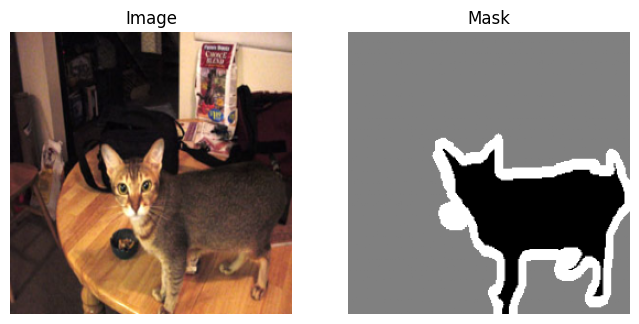

In [16]:
img, mask = next(iter(seg_loader))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(np.transpose(img[0], (1,2,0)))
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask[0,0], cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()


In [17]:
seg_model = models.segmentation.deeplabv3_resnet50(weights="DEFAULT").to(device)
seg_model.eval()


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\ASUS Vivobook Flip S/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:18<00:00, 9.11MB/s] 


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

Предсказание маски

In [18]:
def predict_mask(model, image):
    with torch.no_grad():
        out = model(image.to(device))["out"]
        mask = out.argmax(1).cpu().numpy()[0]
    return mask


Метрика mean IoU

In [19]:
def mean_iou(pred, true):
    pred_fg = (pred > 0)
    true_fg = (true > 0)
    intersection = (pred_fg & true_fg).sum()
    union = (pred_fg | true_fg).sum()
    return intersection / union if union > 0 else 0.0


Эксперименты

V1

In [20]:
ious_v1 = []
examples_v1 = []

for i, (img, mask) in enumerate(seg_loader):
    if i >= 20:
        break
    pred = predict_mask(seg_model, img)
    true = mask[0,0].numpy()
    iou = mean_iou(pred, true)
    ious_v1.append(iou)
    if i < 4:
        examples_v1.append((img[0], true, pred))

mean_iou_v1 = float(np.mean(ious_v1))
mean_iou_v1


0.39401702880859374

V2

In [21]:
def clean_mask(pred):
    labeled, num = ndi.label(pred > 0)
    sizes = ndi.sum(pred > 0, labeled, range(1, num+1))
    keep = sizes > 500
    cleaned = np.zeros_like(pred)
    for idx, k in enumerate(keep):
        if k:
            cleaned[labeled == (idx+1)] = 1
    return cleaned


In [22]:
ious_v2 = []
examples_v2 = []

for i, (img, mask) in enumerate(seg_loader):
    if i >= 20:
        break
    pred = predict_mask(seg_model, img)
    pred2 = clean_mask(pred)
    true = mask[0,0].numpy()
    iou = mean_iou(pred2, true)
    ious_v2.append(iou)
    if i < 4:
        examples_v2.append((img[0], true, pred2))

mean_iou_v2 = float(np.mean(ious_v2))
mean_iou_v2


0.3931419372558594

In [23]:
plt.figure(figsize=(8,8))
for i, (img, true, pred) in enumerate(examples_v1):
    if i >= 4:
        break
    plt.subplot(4,3,3*i+1)
    plt.imshow(np.transpose(img, (1,2,0)))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(4,3,3*i+2)
    plt.imshow(true, cmap="gray")
    plt.title("GT mask")
    plt.axis("off")

    plt.subplot(4,3,3*i+3)
    plt.imshow(pred, cmap="gray")
    plt.title("Pred V1")
    plt.axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png")
plt.close()


In [24]:
plt.figure(figsize=(4,4))
plt.bar(["V1","V2"], [mean_iou_v1, mean_iou_v2])
plt.ylabel("mean IoU")
plt.title("Segmentation modes")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png")
plt.close()


#### Сохранение всего

In [25]:
df = pd.DataFrame([
    ["C1", "classification", "STL10", 42, "SimpleCNN", "Adam", 1e-3, 10, acc_c1, test_acc if best_id=="C1" else None, None, None, None, ""],
    ["C2", "classification", "STL10", 42, "SimpleCNN", "Adam", 1e-3, 10, acc_c2, test_acc if best_id=="C2" else None, None, None, None, ""],
    ["C3", "classification", "STL10", 42, "ResNet18 head-only", "Adam", 1e-3, 10, acc_c3, test_acc if best_id=="C3" else None, None, None, None, ""],
    ["C4", "classification", "STL10", 42, "ResNet18 finetune", "Adam", 1e-4, 10, acc_c4, test_acc if best_id=="C4" else None, None, None, None, ""],
    ["V1", "segmentation", "OxfordIIITPet", 42, "DeepLabV3_ResNet50", "-", "-", "-", None, None, None, None, mean_iou_v1, "base"],
    ["V2", "segmentation", "OxfordIIITPet", 42, "DeepLabV3_ResNet50", "-", "-", "-", None, None, None, None, mean_iou_v2, "clean small components"],
], columns=[
    "experiment_id","task","dataset","seed","model_summary","optimizer","lr",
    "epochs_trained","best_val_accuracy","test_accuracy","precision","recall","mean_iou","notes"
])

df.to_csv("artifacts/runs.csv", index=False)
import pandas as pd

df = pd.DataFrame([
    ["C1", "classification", "STL10", 42, "SimpleCNN", "Adam", 1e-3, 10, acc_c1, test_acc if best_id=="C1" else None, None, None, None, ""],
    ["C2", "classification", "STL10", 42, "SimpleCNN", "Adam", 1e-3, 10, acc_c2, test_acc if best_id=="C2" else None, None, None, None, ""],
    ["C3", "classification", "STL10", 42, "ResNet18 head-only", "Adam", 1e-3, 10, acc_c3, test_acc if best_id=="C3" else None, None, None, None, ""],
    ["C4", "classification", "STL10", 42, "ResNet18 finetune", "Adam", 1e-4, 10, acc_c4, test_acc if best_id=="C4" else None, None, None, None, ""],
    ["V1", "segmentation", "OxfordIIITPet", 42, "DeepLabV3_ResNet50", "-", "-", "-", None, None, None, None, mean_iou_v1, "base"],
    ["V2", "segmentation", "OxfordIIITPet", 42, "DeepLabV3_ResNet50", "-", "-", "-", None, None, None, None, mean_iou_v2, "clean small components"],
], columns=[
    "experiment_id","task","dataset","seed","model_summary","optimizer","lr",
    "epochs_trained","best_val_accuracy","test_accuracy","precision","recall","mean_iou","notes"
])

df.to_csv("artifacts/runs.csv", index=False)


In [26]:
torch.save(best_state, "artifacts/best_classifier.pt")

config = {
    "dataset": "STL10",
    "best_experiment": best_id,
    "architecture": "SimpleCNN" if best_id in ["C1","C2"] else "ResNet18",
    "transforms": best_id,
    "seed": 42,
    "batch_size": batch_size,
    "epochs": 10,
}
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(config, f, indent=4)


In [27]:
hist_best = {"C1": hist_c1, "C2": hist_c2, "C3": hist_c3, "C4": hist_c4}[best_id]

plt.figure(figsize=(8,4))
plt.plot(hist_best["train_acc"], label="train_acc")
plt.plot(hist_best["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title(f"Best run {best_id}")
plt.tight_layout()
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.close()


In [28]:
plt.figure(figsize=(6,4))
plt.bar(["C1","C2","C3","C4"], [acc_c1, acc_c2, acc_c3, acc_c4])
plt.ylabel("val_accuracy")
plt.title("C1–C4 comparison")
plt.tight_layout()
plt.savefig("artifacts/figures/classification_compare.png")
plt.close()


In [30]:
imgs_aug = []
train_full.transform = aug_transform

for _ in range(4):
    img_aug, _ = train_full[0]
    imgs_aug.append(img_aug)

train_full.transform = basic_transform  # вернуть обратно

plt.figure(figsize=(8,4))
for i, im in enumerate(imgs_aug):
    plt.subplot(1,4,i+1)
    plt.imshow(np.transpose(im, (1,2,0)))
    plt.axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png")
plt.close()


In [31]:
plt.figure(figsize=(8,8))
for i, (img, true, pred) in enumerate(examples_v1):
    if i >= 4:
        break
    plt.subplot(4,3,3*i+1)
    plt.imshow(np.transpose(img, (1,2,0)))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(4,3,3*i+2)
    plt.imshow(true, cmap="gray")
    plt.title("GT mask")
    plt.axis("off")

    plt.subplot(4,3,3*i+3)
    plt.imshow(pred, cmap="gray")
    plt.title("Pred V1")
    plt.axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png")
plt.close()


In [32]:
plt.figure(figsize=(4,4))
plt.bar(["V1","V2"], [mean_iou_v1, mean_iou_v2])
plt.ylabel("mean IoU")
plt.title("Segmentation modes")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png")
plt.close()
